In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import RobustScaler
import random
import os
import joblib
from category_encoders import TargetEncoder


SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [4]:
df = pd.read_csv('../data/CreditPrediction.csv')
df = df.drop(columns=['CLIENTNUM', 'Unnamed: 19'])
df = df[(df['Total_Amt_Chng_Q4_Q1'] <= 2.8) & (df['Customer_Age'] <= 80)]
print(f'Размер данных после удаления аномалий: {df.shape[0]}')

Размер данных после удаления аномалий: 10148


In [5]:
target_col = "Credit_Limit"
num_cols = [col for col in df.select_dtypes(include=['int64', 'float64']).columns if col != target_col]
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(num_cols)
print(cat_cols)

['Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']
['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']


In [6]:
print(f'Уникальные значения для категориальных колонок:')

for col_name in cat_cols:
    print(f'{col_name} - {df[col_name].unique()}', end='\n\n')

Уникальные значения для категориальных колонок:
Gender - ['M' 'F' nan]

Education_Level - ['High School' 'Graduate' 'Uneducated' 'Unknown' 'Post-Graduate'
 'Doctorate' 'College']

Marital_Status - ['Married' nan 'Unknown' 'Single' 'Divorced']

Income_Category - ['$60K - $80K' 'Less than $40K' '$80K - $120K' '$40K - $60K' '$120K +'
 'Unknown']

Card_Category - ['Blue' nan 'Gold' 'Silver' 'Platinum']



In [7]:
for col_name in cat_cols:
    df[col_name] = df[col_name].fillna('Unknown')

In [8]:
for col_name in num_cols:
    df[col_name] = df[col_name].fillna(df[col_name].median())

In [9]:
X = df.drop(columns=[target_col])
y = df[target_col]

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f'Train: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Validation: {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'Test: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)')

Train: 6088 (60.0%)
Validation: 2030 (20.0%)
Test: 2030 (20.0%)


In [ ]:
encoder = TargetEncoder(cols=cat_cols, smoothing=10.0, handle_unknown='value')

# Отдельно логарифмируем таргет
y_train_log = np.log(y_train.values)
y_val_log   = np.log(y_val.values)
y_test_log  = np.log(y_test.values)

X_train_enc = encoder.fit_transform(X_train, y_train_log)
X_val_enc = encoder.transform(X_val)
X_test_enc = encoder.transform(X_test)

joblib.dump(encoder, "../artifacts/target_encoder_rf_base_log.pkl")

['../artifacts/target_encoder_nn_base_log.pkl']

In [11]:
scaler = RobustScaler()
X_train_scaled = X_train_enc.copy()
X_train_scaled = scaler.fit_transform(X_train_enc)

X_val_scaled = X_val_enc.copy()
X_val_scaled = scaler.transform(X_val_enc)

X_test_scaled = X_test_enc.copy()
X_test_scaled = scaler.transform(X_test_enc)

In [10]:
# Обучение модели Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

print("Обучение Random Forest модели...")
rf_model.fit(X_train_scaled, y_train_log)
print("Обучение завершено!")

Обучение Random Forest модели...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s


Обучение завершено!


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.3s finished


In [14]:
# Функция для оценки важности признаков
def plot_feature_importance(model, X_train, top_n=15):
    """Рисует график важности признаков"""
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    top_features = feature_importance.head(top_n)
    ax.barh(range(len(top_features)), top_features['importance'].values)
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features['feature'].values)
    ax.set_xlabel('Importance', fontsize=12)
    ax.set_title(f'Top {top_n} Feature Importance', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    return feature_importance

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


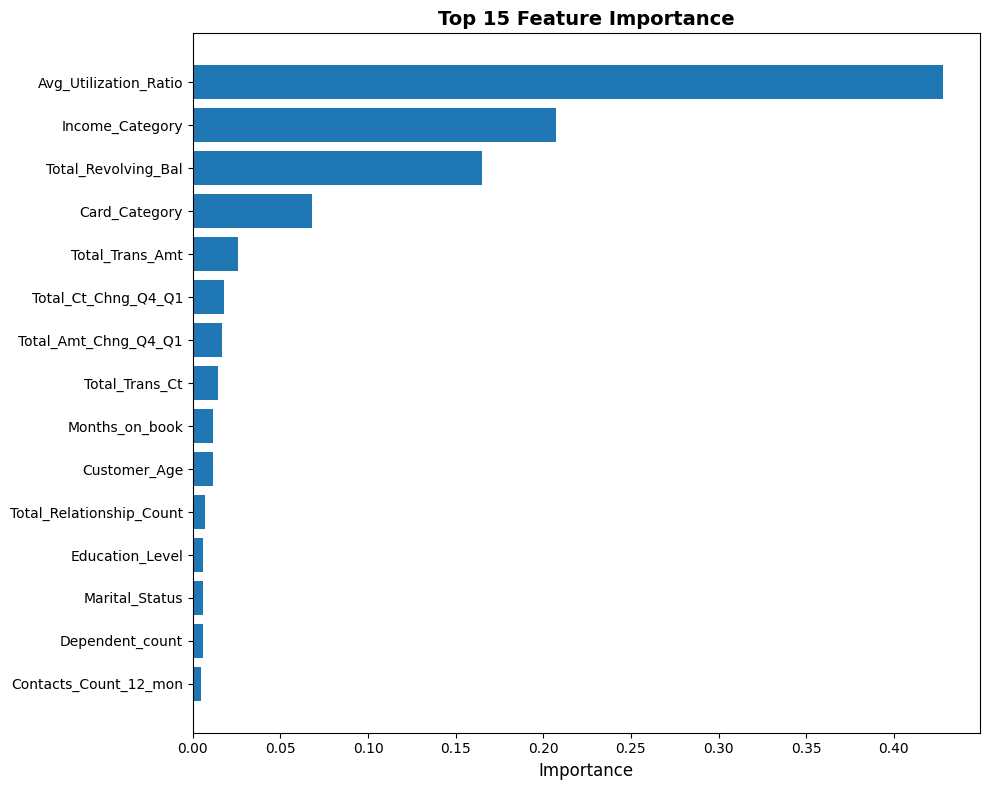

In [15]:
# Делаем предсказания на всех наборах данных
y_train_pred_log = rf_model.predict(X_train_scaled)
y_val_pred_log = rf_model.predict(X_val_scaled)
y_test_pred_log = rf_model.predict(X_test_scaled)

# Преобразуем обратно из логарифмической шкалы
y_train_pred = np.exp(y_train_pred_log)
y_val_pred = np.exp(y_val_pred_log)
y_test_pred = np.exp(y_test_pred_log)

y_train_actual = np.exp(y_train_log)
y_val_actual = np.exp(y_val_log)
y_test_actual = np.exp(y_test_log)

# Визуализируем важность признаков
feature_importance = plot_feature_importance(rf_model, X_train_enc, top_n=15)

In [ ]:
def calculate_rf_metrics(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f'\n{dataset_name}:')
    print(f'  MSE:   {mse:.4f}')
    print(f'  RMSE:  {rmse:.4f}')
    print(f'  MAE:   {mae:.4f}')
    print(f'  R²:    {r2:.4f}')
    
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

print('=' * 50)
print('Метрики Random Forest модели')
print('=' * 50)

train_rf_metrics = calculate_rf_metrics(y_train_actual, y_train_pred, 'TRAIN')
val_rf_metrics = calculate_rf_metrics(y_val_actual, y_val_pred, 'VALIDATION')
test_rf_metrics = calculate_rf_metrics(y_test_actual, y_test_pred, 'TEST')

print('\n' + '=' * 50)

joblib.dump(rf_model, '../artifacts/model_random_forest.pkl')
print("\nМодель сохранена в '../artifacts/model_random_forest.pkl'")

Метрики Random Forest модели

TRAIN:
  MSE:   3733742.3361
  RMSE:  1932.2894
  MAE:   638.7783
  R²:    0.9558

VALIDATION:
  MSE:   11091980.6758
  RMSE:  3330.4625
  MAE:   1235.5850
  R²:    0.8583

TEST:
  MSE:   10390908.2244
  RMSE:  3223.4932
  MAE:   1219.2036
  R²:    0.8717


Модель сохранена в '../artifacts/model_random_forest.pkl'


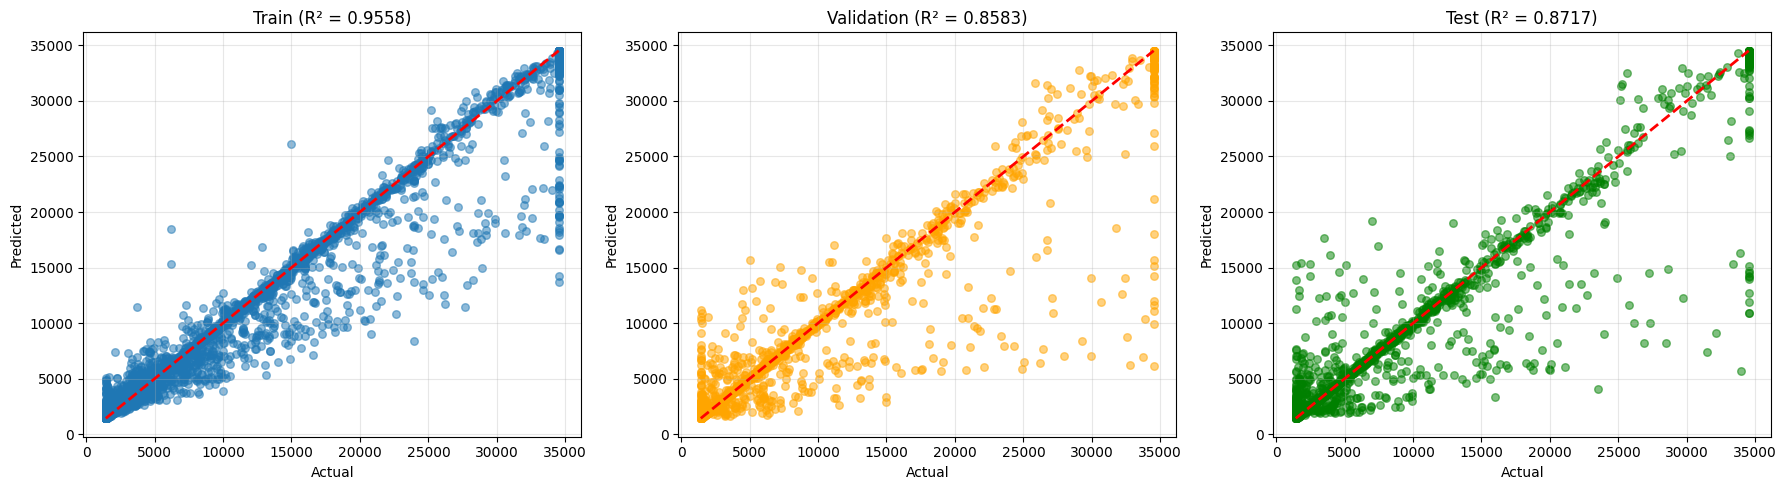

In [14]:
# Визуализация предсказаний vs реальные значения
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Train
axes[0].scatter(y_train_actual, y_train_pred, alpha=0.5, s=30)
axes[0].plot([y_train_actual.min(), y_train_actual.max()], 
             [y_train_actual.min(), y_train_actual.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Train (R² = {train_rf_metrics["R2"]:.4f})')
axes[0].grid(True, alpha=0.3)

# Validation
axes[1].scatter(y_val_actual, y_val_pred, alpha=0.5, s=30, color='orange')
axes[1].plot([y_val_actual.min(), y_val_actual.max()], 
             [y_val_actual.min(), y_val_actual.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title(f'Validation (R² = {val_rf_metrics["R2"]:.4f})')
axes[1].grid(True, alpha=0.3)

# Test
axes[2].scatter(y_test_actual, y_test_pred, alpha=0.5, s=30, color='green')
axes[2].plot([y_test_actual.min(), y_test_actual.max()], 
             [y_test_actual.min(), y_test_actual.max()], 'r--', lw=2)
axes[2].set_xlabel('Actual')
axes[2].set_ylabel('Predicted')
axes[2].set_title(f'Test (R² = {test_rf_metrics["R2"]:.4f})')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
import optuna
from sklearn.model_selection import cross_val_score
import joblib

optuna.logging.set_verbosity(optuna.logging.WARNING)

print("=" * 50)
print("Тюнинг гиперпараметров Random Forest (Optuna)")
print("=" * 50)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 2000, step=50),
        'max_depth': trial.suggest_int('max_depth', 5, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 50),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 40),
        'random_state': SEED
    }
    
    model = RandomForestRegressor(**params)
    scores = cross_val_score(model, X_train_scaled, y_train_log, cv=3, scoring='r2', n_jobs=1)
    return scores.mean()

study = optuna.create_study(
    direction='maximize', 
    sampler=optuna.samplers.TPESampler(seed=SEED)
)

print("\nЗапуск оптимизации...")
study.optimize(objective, n_trials=100, n_jobs=-1, show_progress_bar=True)

print(f"\nЛучшие параметры: {study.best_params}")
print(f"Лучший R² (CV): {study.best_value:.4f}")

best_rf = RandomForestRegressor(**study.best_params, random_state=SEED)
best_rf.fit(X_train_scaled, y_train_log)

y_val_pred_best = np.exp(best_rf.predict(X_val_scaled))
y_test_pred_best = np.exp(best_rf.predict(X_test_scaled))

print(f"\nValidation | R²: {r2_score(y_val_actual, y_val_pred_best):.4f} | RMSE: {np.sqrt(mean_squared_error(y_val_actual, y_val_pred_best)):.4f}")
print(f"Test      | R²: {r2_score(y_test_actual, y_test_pred_best):.4f} | RMSE: {np.sqrt(mean_squared_error(y_test_actual, y_test_pred_best)):.4f}")

joblib.dump(best_rf, '../artifacts/model_random_forest_best_optuna.pkl')
print("\nМодель сохранена")

z:\projects\AIE\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Тюнинг гиперпараметров Random Forest (Optuna)

Запуск оптимизации...


Best trial: 88. Best value: 0.84756: 100%|██████████| 100/100 [14:42<00:00,  8.82s/it]



Лучшие параметры: {'n_estimators': 700, 'max_depth': 34, 'min_samples_split': 4, 'min_samples_leaf': 5}
Лучший R² (CV): 0.8476

Validation | R²: 0.8586 | RMSE: 3327.2832
Test      | R²: 0.8724 | RMSE: 3214.4940

Модель сохранена
